The input files should first be interpolated onto a common grid in order to compare them

# Imports

In [1]:
# %pip install icecream
# %pip install scikit-image

In [2]:
#Imports:
#If there are changes in other file, it will be taken into account automatically
%load_ext autoreload 
%autoreload 2 

import os
import glob
import numpy as np
import xarray as xr
import cf_xarray as cfxr
from pathlib import Path
import cftime
import pandas as pd
import matplotlib
from pprint import pprint
import importlib

import sys

#Import classes and functions from the urclimask package:

from urclimask.urban_areas import (
    UrbanVicinity
)
from urclimask.utils import (
    kelvin2degC,
    traverseDir,
    fix_360_longitudes,
    RCM_DICT,
    load_ucdb_city
)

from urclimask.UHI_analysis import (
    UrbanIsland
)
from urclimask.GHCNd_stations import (
    load_ghcnd_stations,
    get_ghcnd_df,
    get_valid_timeseries,
    available_vars,
    inside_city
)

import geopandas as gpd
import matplotlib.pyplot as plt




# Variables:

In [3]:
##Variables to be modified in each case:

# path = '/lustre/gmeteo/ASNA/DATA/I4C/CMIP6/DD/ALPX-3f/BCCR-UCAN/ERA5/evaluation/r1i1p1f1/WRF451R-CI4C/v1-r1/6hr/ta1000/v20240710'
path = ''
file = 'tsl_ALPX-3f_ERA5_evaluation_r1i1p1f1_BCCR-UCAN_WRF451R-CI4C_v1-r1_6hr_199901010000-199912311800.nc'
city = "Paris"
lon_city = 2.35
lat_city = 48.85

urban_var = 'sfturf'#Name of the urban-rural field introduced in the model

#Mask parameters:
urban_th = 60
urban_sur_th = 15
orog_diff = 100
sftlf_th = 70
ratio_r2u = 1 #o 2 #Rural cell number per urban one
min_city_size = 80  #It is the minimum number of grid points that the city should have to be considered in the analysis.
                    #Adjust depending on the city size, for Paris 80 is a good value, for smaller cities it should be smaller and for bigger cities 
                    #it should be bigger. 
lon_lim = 0.7
lat_lim = 0.7

domain_resolution = 3 #In Km
# base_filename = f'{city}-{domain}_ECMWF-ERA5_{scenario}_r1i1p1f1_{model}'


#Path and file name of the official city boundary poligons file :
city_polygon_path ='../utils/'#The same file for all cities
poligon_info_file='city_polygons_clean_file.gpkg'

In [4]:
##Information obtained from the file name:
variable, domain, driving_model, scenario, member, institution, model, version, time_interval, time_period = file.split("_")

#Folder to save results
base_output_dir = 'urclimask/Results'# It create the folder
output_dir = f"{base_output_dir}/{city}-{domain}_{model}" #It construct file names
os.makedirs(output_dir, exist_ok = True) #The directory is only created if it does'nt exist

In [5]:
##Input fields of the model

#Define the common part of the root
root_nextcloud = '../I4C_CPRCM_DATA/'

#Search for necessary files:
file_sfturf = glob.glob(        #urban_area_fraction=Percentage of the Grid Cell Occupied by City
        f"{root_nextcloud}{domain}/{institution}/{driving_model}/{scenario}/{member}/{model}/{version}/fx/sfturf/*/*.nc" 
)
file_orog = glob.glob(        #Surface altitude
        f"{root_nextcloud}{domain}/{institution}/{driving_model}/{scenario}/{member}/{model}/{version}/fx/orog/*/*.nc" 
)
file_sftlf = glob.glob(        #land_area_fraction=Percentage of the Grid Cell Occupied by Land
        f"{root_nextcloud}{domain}/{institution}/{driving_model}/{scenario}/{member}/{model}/{version}/fx/sftlf/*/*.nc" 
)

# Masks obtention

In [6]:
#Open fields datasets
ds_sfturf = xr.open_dataset(file_sfturf[0])
ds_orog = xr.open_dataset(file_orog[0])
ds_sftlf = xr.open_dataset(file_sftlf[0])

ds_sfturf = fix_360_longitudes(ds_sfturf)#Repository's urclimask function. It's defined in urclimask/utils.py. 
                                        #It converts longitudes from 0–360° to -180–180°
ds_orog = fix_360_longitudes(ds_orog)
ds_sftlf = fix_360_longitudes(ds_sftlf)

In [7]:

#It creates the object urban from UrbanVicinity (urclimask repository)
URBAN = UrbanVicinity(
    urban_sur_th = urban_sur_th,
    orog_diff = orog_diff,
    sftlf_th = sftlf_th,
    ratio_r2u = ratio_r2u,
    min_city_size = min_city_size,
    lon_city = lon_city,
    lat_city = lat_city,
    lon_lim = lon_lim,
    lat_lim = lat_lim,
    model = model,
    domain = domain,
    urban_th = urban_th,
    urban_var = urban_var
)

In [8]:
# Crop area around de city in the fields datasets
ds_sfturf = URBAN.crop_area_city(ds = ds_sfturf, res = domain_resolution)
ds_orog = URBAN.crop_area_city(ds = ds_orog, res = domain_resolution)
ds_sftlf = URBAN.crop_area_city(ds = ds_sftlf, res = domain_resolution)

In [9]:
# Define masks using the parameters above
sfturf_mask, sfturf_sur_mask, orog_mask, sftlf_mask = URBAN.define_masks(
    ds_sfturf = ds_sfturf, #
    ds_orog = ds_orog, 
    ds_sftlf = ds_sftlf,
)

# sfturf_mask: Urban mask, identifies urban grid cells based on the urban variable (sftimf) and the defined urban threshold (urban_th).
# sfturf_sur_mask: Urban surroundings mask, identifies grid cells in the transition zone between urban and rural areas based on the urban surface threshold (urban_sur_th).
# orog_mask: Orography mask, identifies grid cells where the elevation difference is less than the defined threshold (orog_diff). 


/nfs/home/gmeteo/moralesi/Repositorios/T32-CPRCM-hub/urclimask/urclimask/urban_areas.py:151: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned_mask = morphology.remove_small_objects(labeled_mask, min_size=self.min_city_size)


In [10]:
## Final rural-urban mask:
# Starting from the city, it progressively expands the surrounding area until it finds enough comparable rural cells, 
# excluding sea, areas with non-comparable orography, and peri-urban zones.
urmask = URBAN.select_urban_vicinity(
    sfturf_mask = sfturf_mask, 
    orog_mask = orog_mask,
    sftlf_mask = sftlf_mask,
    sfturf_sur_mask = sfturf_sur_mask
)
#ratio_r2u-> Criteria for enough riral cells, predefined (self)


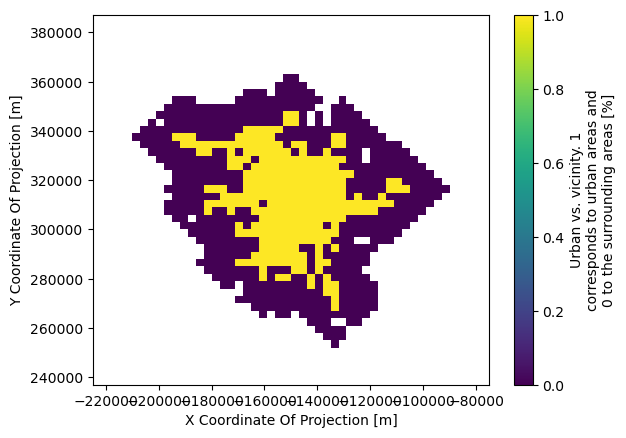

In [11]:
#Mask representation:
urmask.urmask.plot()

# Heat/humidity island:

In [12]:
#City and rural variable differences: Urban heat islan/ humidity island 

## Mean variable over urban points
urban_mask = urmask.urmask == 1#Urban mask definition

#Find files:
files = glob.glob(f"{root_nextcloud}{domain}/{institution}/{driving_model}/{scenario}/{member}/{model}/{version}/{time_interval}/{variable}/{file}")
if files==[]:
    files = glob.glob(f"{root_nextcloud}{domain}/{institution}/{driving_model}/{scenario}/{member}/{model}/{version}/{time_interval}/{variable}/*/{file}")

#Open files, change units and longitudes
ds = xr.open_dataset(files[0])
ds = kelvin2degC(ds, variable)#K->ºC
ds = fix_360_longitudes(ds)#0–360 -> -180–180

#Selection of urban points and calculation of the mean
variable_city = ds[variable].where(urban_mask)
variable_city_mean = float(variable_city.mean())

## Mean variable over rural points:
urban_mask = urmask.urmask == 0#Rural mask definition
variable_rural = ds[variable].where(urban_mask) #Selection of urban points
variable_rural_mean = float(variable_rural.mean())  #Calculation of the mean

variable_dif = variable_city_mean-variable_rural_mean
print('Difference between the urban mean value and the rural one: ', variable_dif)


Difference between the urban mean value and the rural one:  0.1934070587158203


# Urban and rural variable values with the official city boundary

In [13]:
#City polygon extraction

#Read file
gdf = gpd.read_file(city_polygon_path+poligon_info_file)

# #clean the geopandas file: Only did it onces.
# # Remove \ufeff from colum names
# ucdb_info .columns = [col.lstrip("\ufeff") for col in ucdb_info.columns]
# # Save the clean file:
# ucdb_info .to_file("archivo_limpio.gpkg", driver="GPKG")#to save as geopandas file

#Find the city in the file:
matches = gdf[gdf["GC_UCN_MAI_2025"].astype(str).str.contains(city, case=False, na=False)]
# matches



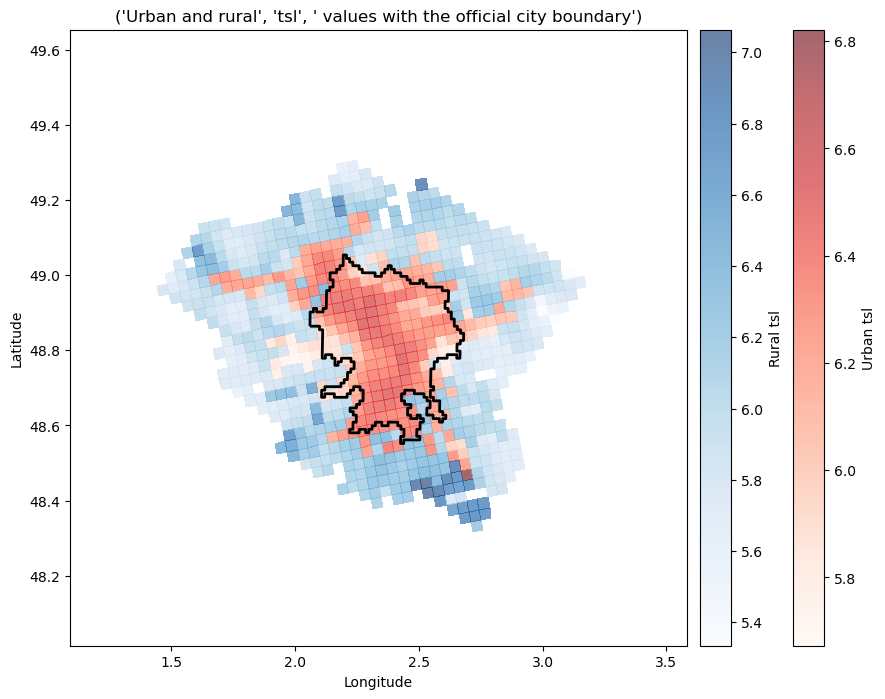

Difference between the urban mean  tsl  value and the rural one:  0.1934070587158203


In [14]:
##Figure:

fig, ax = plt.subplots(figsize=(10, 8))

#Take a time and sdepth to represent (adapt to variable coordinates)
city = variable_city.isel(time=0).isel(sdepth=1)
rural = variable_rural.isel(time=0).isel(sdepth=1)

# First plot layer
im1 = ax.pcolormesh(city.lon, city.lat, city, cmap="Reds", alpha=0.6, shading="auto", zorder=1)

# Second plot layer
im2 = ax.pcolormesh(rural.lon, rural.lat, rural, cmap="Blues", alpha=0.6, shading="auto", zorder=2)

# City poligon in lon/lat
matches_lonlat = matches.to_crs("EPSG:4326")#Change the geopandas (city polygon) coordinates

#Third plot layer
matches_lonlat.boundary.plot(ax=ax, color="black", linewidth=2, zorder=10)

# Color bars:
cbar1 = plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.08)#urban
label1_str="Urban "+ variable
cbar1.set_label(label1_str)

cbar2 = plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.02)#rural
label2_str="Rural "+ variable
cbar2.set_label(label2_str)

#labels and title
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
title_str='Urban and rural',variable, ' values with the official city boundary'
ax.set_title(title_str)

plt.show()
print('Difference between the urban mean ',variable, ' value and the rural one: ', variable_dif)


# Diurnal cicle:

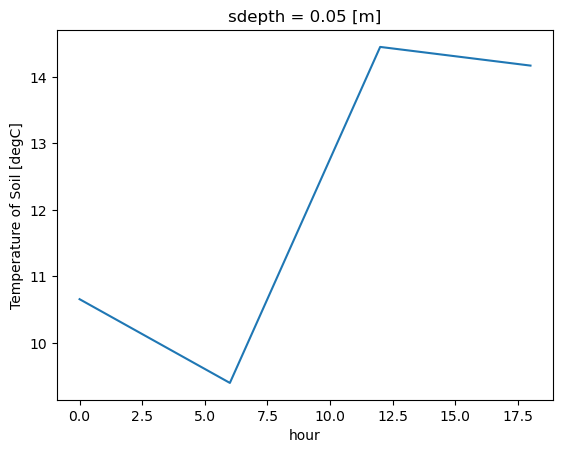

In [16]:
##CITY:

#Promediate over the spatial dimensions (x, y)
diurnal_cicle_city = variable_city.mean(dim='x').mean(dim='y')
diurnal_cicle_city = diurnal_cicle_city.isel(sdepth=0)#Particular case, quit it for othe cases

#Transform time coordinate to datetime
diurnal_cicle_city = diurnal_cicle_city.assign_coords(
    time=np.array([
        np.datetime64(f"{t.year:04d}-{t.month:02d}-{t.day:02d}T{t.hour:02d}:{t.minute:02d}:{t.second:02d}")
        for t in diurnal_cicle_city.time.values]))

#Promediate over the time dimension to get the diurnal cicle, in our case hour by hour
diurnal_cicle_city = diurnal_cicle_city.groupby('time.hour').mean(dim='time')

#If the data is 6-hourly, the plot will show only 4 points.
#If the data is hourly, the plot will show 24 points, giving a better representation.

#Diurnal cicle plot:
diurnal_cicle_city.plot()



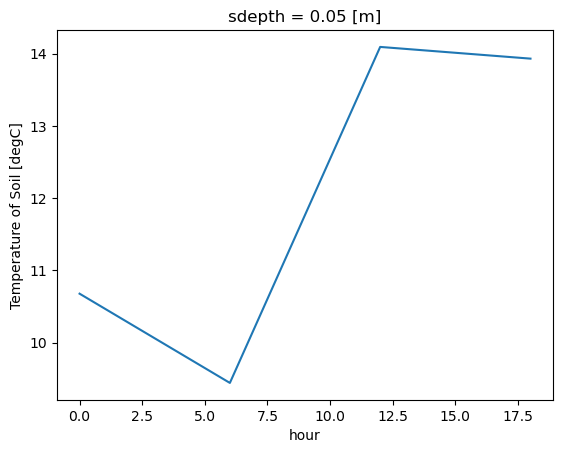

In [19]:
##URBAN:

#Promediate over the spatial dimensions (x, y)
diurnal_cicle_rural = variable_rural.mean(dim='x').mean(dim='y')
diurnal_cicle_rural = diurnal_cicle_rural.isel(sdepth=0)#Particular case, quit it for othe cases

#Transform time coordinate to datetime
diurnal_cicle_rural = diurnal_cicle_rural.assign_coords(
    time=np.array([
        np.datetime64(f"{t.year:04d}-{t.month:02d}-{t.day:02d}T{t.hour:02d}:{t.minute:02d}:{t.second:02d}")
        for t in diurnal_cicle_rural.time.values]))

#Promediate over the time dimension to get the diurnal cicle, in our case hour by hour
diurnal_cicle_rural = diurnal_cicle_rural.groupby('time.hour').mean(dim='time')

#If the data is 6-hourly, the plot will show only 4 points.
#If the data is hourly, the plot will show 24 points, giving a better representation.

#Diurnal cicle plot:
diurnal_cicle_rural.plot()

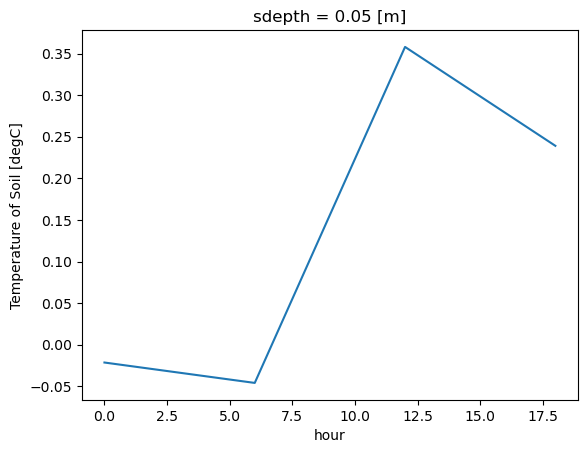

In [21]:
##DIFFERENCE BETWEEN URBAN AND RURAL DIURNAL CICLE:
diurnal_cicle_diff=diurnal_cicle_city-diurnal_cicle_rural
diurnal_cicle_diff.plot()

